# Rule-Unexplained Failures — AI4I 2020 Predictive Maintenance

## Objective

Investigate failures that are **not covered by the documented HDF/PWF/OSF rules**.

We call these:

> **rule-unexplained failures**

We do not automatically call them unpredictable.

### Validation protocol

Notebook 07 uses the **development split only** for all residual analysis and ML detection experiments.
The final 20% holdout is reserved for Notebook 08 and is not used for residual counting, model fitting,
threshold analysis, or interpretation in this notebook.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold

DATA_PATH = Path("../data/raw/ai4i2020.csv")
df = pd.read_csv(DATA_PATH)

TARGET = "Machine failure"
RANDOM_STATE = 42

# Derived variables
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_w"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
)

strain_limits = {"L": 11000, "M": 12000, "H": 13000}
df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
df["strain_limit"] = df["Type"].map(strain_limits)
df["strain_ratio"] = df["wear_torque"] / df["strain_limit"]

# Strict development / final-holdout boundary.
split_point = int(len(df) * 0.8)
dev = df.iloc[:split_point].copy()
final_holdout = df.iloc[split_point:].copy()

# Every analysis in this notebook uses development data only.
analysis_df = dev.copy()

print("Development rows:", len(dev))
print("Development failures:", int(dev[TARGET].sum()))
print("Final holdout rows reserved for Notebook 08:", len(final_holdout))
print("Final holdout is excluded from all Notebook 07 analysis.")

Development rows: 8000
Development failures: 300
Final holdout rows reserved for Notebook 08: 2000
Final holdout is excluded from all Notebook 07 analysis.


## 1. Recreate documented HDF/PWF/OSF rules

These are deterministic benchmark rules, not ML features.

Rule coverage and residual counts below are computed on **development data only**.

In [2]:
analysis_df["rule_HDF"] = (
    (analysis_df["temp_diff"] < 8.6)
    & (analysis_df["Rotational speed [rpm]"] < 1380)
)

analysis_df["rule_PWF"] = (
    (analysis_df["power_w"] < 3500)
    | (analysis_df["power_w"] > 9000)
)

analysis_df["rule_OSF"] = (
    analysis_df["wear_torque"] > analysis_df["strain_limit"]
)

analysis_df["rule_any"] = (
    analysis_df["rule_HDF"]
    | analysis_df["rule_PWF"]
    | analysis_df["rule_OSF"]
)

analysis_df["rule_unexplained"] = (
    (analysis_df[TARGET] == 1)
    & (~analysis_df["rule_any"])
)

print("Development failures:", int(analysis_df[TARGET].sum()))
print("Rule-covered failures:", int(((analysis_df[TARGET] == 1) & analysis_df["rule_any"]).sum()))
print("Rule-unexplained failures:", int(analysis_df["rule_unexplained"].sum()))
print(
    "Rule-unexplained percentage:",
    round(analysis_df.loc[analysis_df[TARGET] == 1, "rule_unexplained"].mean() * 100, 2),
    "%"
)

Development failures: 300
Rule-covered failures: 259
Rule-unexplained failures: 41
Rule-unexplained percentage: 13.67 %


## 2. Failure-mode composition of rule-unexplained cases

This helps determine whether the residual group is associated with particular
failure-mode indicators.

In [3]:
mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

rule_unexplained_mode_counts = (
    analysis_df.loc[analysis_df["rule_unexplained"], mode_cols]
      .sum()
      .sort_values(ascending=False)
)

rule_unexplained_mode_counts

TWF    34
RNF     1
HDF     0
PWF     0
OSF     0
dtype: int64

In [4]:
mode_comparison = pd.DataFrame({
    "all_failures": analysis_df.loc[analysis_df[TARGET] == 1, mode_cols].sum(),
    "rule_unexplained_failures": analysis_df.loc[analysis_df["rule_unexplained"], mode_cols].sum()
})

mode_comparison["residual_share_percent"] = (
    mode_comparison["rule_unexplained_failures"]
    / mode_comparison["rule_unexplained_failures"].sum()
    * 100
)

mode_comparison

,all_failures,rule_unexplained_failures,residual_share_percent
TWF,36,34,97.142857
HDF,115,0,0.000000
PWF,85,0,0.000000
OSF,77,0,0.000000
RNF,1,1,2.857143


## 3. Compare sensor/derived distributions

Compare:
- normal observations in development data
- rule-covered failures in development data
- rule-unexplained failures in development data

In [5]:
analysis_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

analysis_df["analysis_group"] = np.select(
    [
        analysis_df[TARGET].eq(0),
        analysis_df[TARGET].eq(1) & analysis_df["rule_any"],
        analysis_df["rule_unexplained"]
    ],
    [
        "Normal",
        "Rule-covered failure",
        "Rule-unexplained failure"
    ],
    default="Other"
)

group_summary = (
    analysis_df.groupby("analysis_group")[analysis_features]
      .agg(["count", "mean", "median", "std"])
)

group_summary

Air temperature [K]                               \
                                       count        mean median       std   
analysis_group                                                              
Normal                                  7700  300.374597  300.5  1.993685   
Rule-covered failure                     259  301.259846  302.0  1.996317   
Rule-unexplained failure                  41  300.841463  300.6  1.753422   

                         Process temperature [K]                               \
                                           count        mean median       std   
analysis_group                                                                  
Normal                                      7700  310.148909  310.3  1.541376   
Rule-covered failure                         259  310.404247  310.6  1.355931   
Rule-unexplained failure                      41  310.343902  310.6  1.438237   

                         Rotational speed [rpm]               ...  \
                                          count         mean  ...   
analysis_group                                                ...   
Normal                                     7700  1541.406494  ...   
Rule-covered failure                        259  1493.312741  ...   
Rule-unexplained failure                     41  1540.902439  ...   

                              power_w              wear_torque               \
                               median          std       count         mean   
analysis_group                                                                
Normal                    6241.428305  1013.361893        7700  4230.932299   
Rule-covered failure      7827.780751  1904.700811         259  6855.632046   
Rule-unexplained failure  6063.734588   870.349842          41  7358.826829   

                                              strain_ratio            \
                          median          std        count      mean   
analysis_group                                                         
Normal                    3977.8  2715.575733         7700  0.369189   
Rule-covered failure      7051.2  4443.146952          259  0.607830   
Rule-unexplained failure  7718.5  2389.188814           41  0.632009   

                                              
                            median       std  
analysis_group                                
Normal                    0.347550  0.238318  
Rule-covered failure      0.603750  0.397676  
Rule-unexplained failure  0.634375  0.207702  

[3 rows x 36 columns]

## 4. Visualize useful comparisons

These plots are descriptive and use development data only. Extreme small bins should not be treated as strong
evidence by themselves.

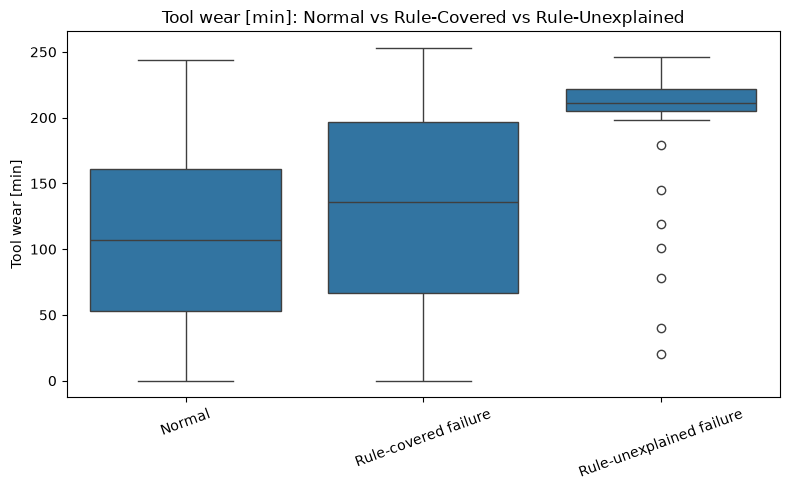

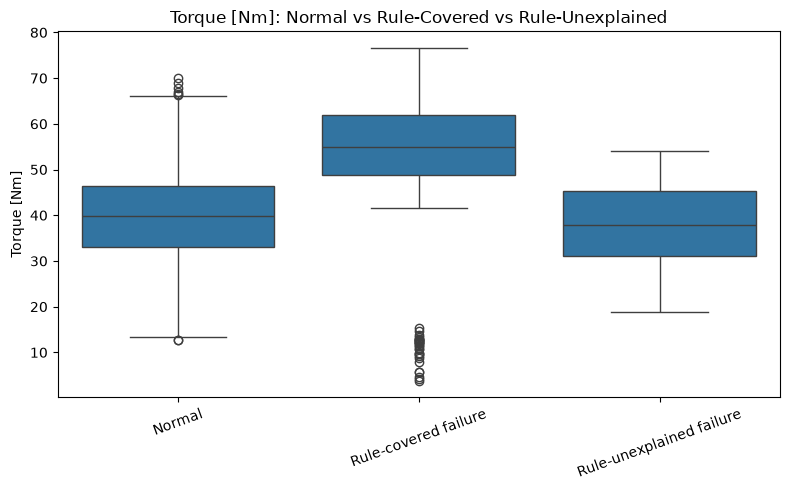

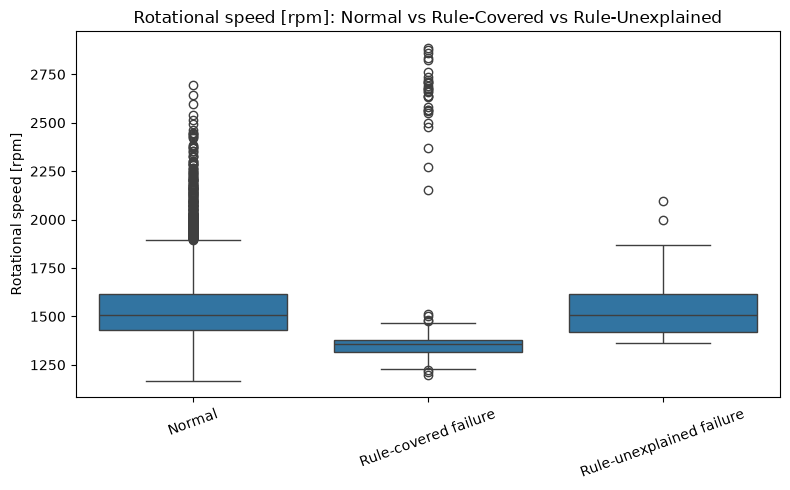

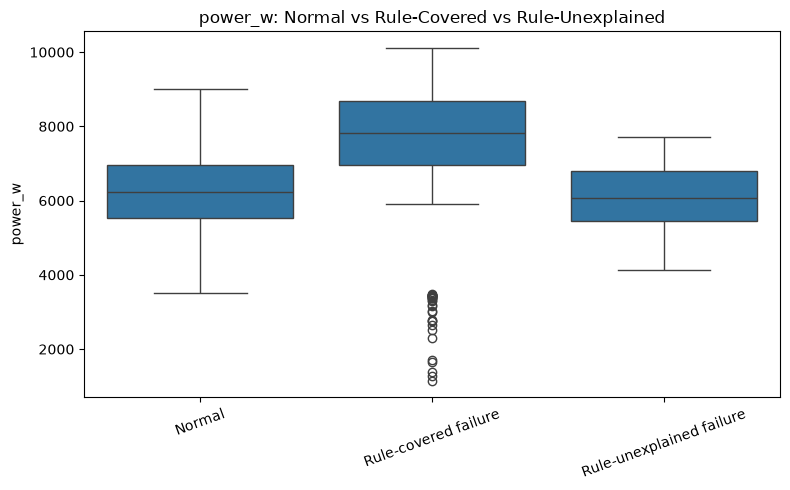

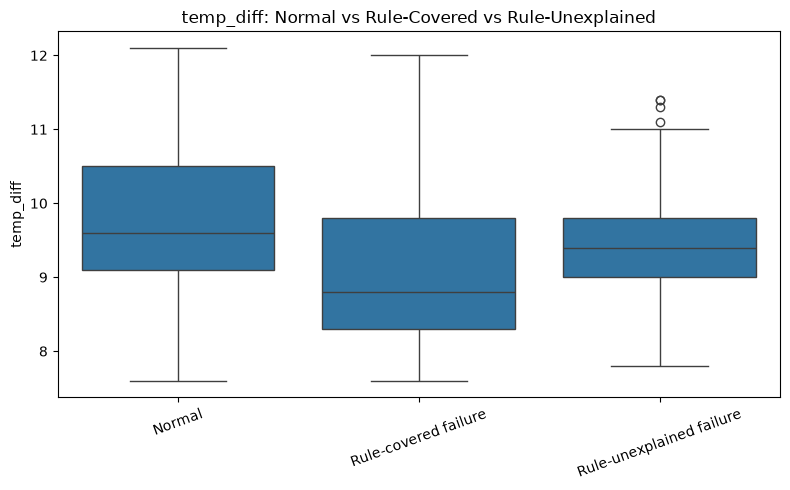

In [6]:
for feature in [
    "Tool wear [min]",
    "Torque [Nm]",
    "Rotational speed [rpm]",
    "power_w",
    "temp_diff"
]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=analysis_df[analysis_df["analysis_group"].isin(
            ["Normal", "Rule-covered failure", "Rule-unexplained failure"]
        )],
        x="analysis_group",
        y=feature
    )
    plt.title(f"{feature}: Normal vs Rule-Covered vs Rule-Unexplained")
    plt.xlabel("")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 5. Show the individual rule-unexplained cases

Cases shown here come from development data only.

In [7]:
residual_cols = [
    "UDI", "Product ID", "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff", "power_w", "wear_torque", "strain_ratio",
    TARGET,
    *mode_cols
]

rule_unexplained_cases = (
    analysis_df.loc[analysis_df["rule_unexplained"], residual_cols]
      .sort_values("UDI")
)

print("Number of rule-unexplained development cases:", len(rule_unexplained_cases))
display(rule_unexplained_cases)

Number of rule-unexplained development cases: 41


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff,power_w,wear_torque,strain_ratio,Machine failure,TWF,HDF,PWF,OSF,RNF
77,78,L47257,L,298.8,308.9,1455,41.3,208,10.1,6292.767165,8590.4,0.780945,1,1,0,0,0,0
1087,1088,H30501,H,296.9,307.8,1549,35.8,206,10.9,5807.150244,7374.8,0.567292,1,1,0,0,0,0
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,11.1,6811.266088,1808.0,0.139077,1,0,0,0,0,0
1509,1510,L48689,L,298.0,308.5,1429,37.7,220,10.5,5641.598783,8294.0,0.754000,1,1,0,0,0,0
1682,1683,H31096,H,297.9,307.4,1604,36.1,225,9.5,6063.734588,8122.5,0.624808,1,1,0,0,0,0
1763,1764,L48943,L,298.2,307.6,1511,31.0,209,9.4,4905.178050,6479.0,0.589000,1,1,0,0,0,0
1996,1997,M16856,M,298.4,308.0,1416,38.2,198,9.6,5664.417218,7563.6,0.630300,1,1,0,0,0,0
2166,2167,M17026,M,299.6,309.2,1867,23.4,225,9.6,4574.975718,5265.0,0.438750,1,1,0,0,0,0
2244,2245,M17104,M,299.3,308.4,1542,37.5,203,9.1,6055.419840,7612.5,0.634375,1,1,0,0,0,0
2671,2672,M17531,M,299.7,309.3,1399,41.9,221,9.6,6138.473078,9259.9,0.771658,1,1,0,0,0,0


## 6. Test whether leakage-safe ML detects residual failures

Use out-of-fold probabilities **within the development split only**, so each development case is evaluated by
a model that did not train on that case.

The final holdout is not used here. This is a detection experiment, not evidence that the model has discovered
a new physical failure mechanism.

In [8]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

X = analysis_df[feature_columns].reset_index(drop=True)
y = analysis_df[TARGET].astype(int).reset_index(drop=True)

preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Type"]),
        ("num", "passthrough", [c for c in feature_columns if c != "Type"])
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof = np.zeros(len(analysis_df), dtype=float)

for train_idx, test_idx in cv.split(X, y):
    m = clone(model)
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

analysis_df["ml_oof_risk"] = oof

print("OOF predictions generated for development rows:", len(analysis_df))
print("Final holdout rows excluded from this experiment:", len(final_holdout))

OOF predictions generated for development rows: 8000
Final holdout rows excluded from this experiment: 2000


## 7. Residual failure detection at several thresholds

Because a 0.50 threshold is arbitrary, inspect multiple operating points instead of
claiming one threshold is universally correct.

All measurements below are calculated on development-data residual failures only.

In [9]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

residual_rows = []

residual_mask = analysis_df["rule_unexplained"]

for threshold in thresholds:
    detected = analysis_df.loc[residual_mask, "ml_oof_risk"] >= threshold

    residual_rows.append({
        "threshold": threshold,
        "rule_unexplained_count": int(residual_mask.sum()),
        "detected_by_ml": int(detected.sum()),
        "detected_percent": float(detected.mean() * 100)
    })

residual_detection = pd.DataFrame(residual_rows)

residual_detection

,threshold,rule_unexplained_count,detected_by_ml,detected_percent
0,0.3,41,3,7.317073
1,0.4,41,0,0.000000
2,0.5,41,0,0.000000
3,0.6,41,0,0.000000
4,0.7,41,0,0.000000


## 8. Compare OOF risk distributions

If rule-unexplained failures receive higher OOF risk than normal development observations, that
is evidence that the residual group contains some learnable statistical signal.
It does not identify a causal mechanism.

In [10]:
risk_summary = (
    analysis_df.groupby("analysis_group")["ml_oof_risk"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

risk_summary

,count,mean,median,std,min,max
analysis_group,,,,,,
Normal,7700,0.014833,0.000000,0.049238,0.000000,0.839854
Rule-covered failure,259,0.817034,0.853866,0.134721,0.390313,0.992724
Rule-unexplained failure,41,0.086963,0.060509,0.091502,0.000000,0.329731


## Conclusion

Base the conclusion on the computed **development-only** residual analysis.

Allowed conclusions include:
- the residual group contains detectable statistical signal;
- the residual group is weakly detected by the tested model;
- evidence is insufficient to determine whether the residual group is intrinsically unpredictable.

Do not call rule-unexplained failures "provably unpredictable" without substantially stronger evidence.

Notebook 08 performs the single final evaluation on the untouched holdout.